0 6.662627220153809 1.0010000467300415
500 0.018465174362063408 0.8555789589881897
1000 0.00330454483628273 0.6451740264892578
1500 0.0004245312593411654 0.539212167263031
2000 0.00016861496260389686 0.5064489245414734
2500 0.00014810889842920005 0.5006840229034424
3000 0.00014061600086279213 0.5001713633537292
3500 0.0001318588765570894 0.5001248121261597
4000 0.00012570417311508209 0.5001330971717834
4500 0.0036497972905635834 0.500146746635437
*******************************************
0 0.031033946201205254 0.9990000128746033
500 0.0021362705156207085 0.627579927444458
1000 0.0001195960066979751 0.5130265951156616
1500 8.769790292717516e-05 0.5004783272743225
2000 7.943954551592469e-05 0.500083863735199
2500 7.186565198935568e-05 0.5000759959220886
3000 6.571353151230142e-05 0.5000851154327393
3500 8.711539703654125e-05 0.500098466873169
4000 6.099578968132846e-05 0.5001842975616455
4500 5.056459121988155e-05 0.5000399947166443
*******************************************
0 0.03111

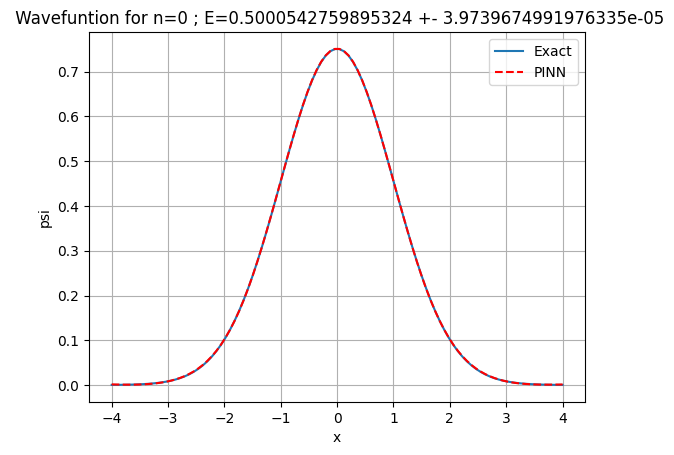

In [5]:
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

x=torch.linspace(-4,4,100).reshape(-1,1)
x.requires_grad = True


model=nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,1),
)

def derivative(y,x):
    return torch.autograd.grad(y,x,grad_outputs=torch.ones_like(y),create_graph=True)[0]

ES=[]
for n in range(5):
    E=nn.Parameter(torch.tensor([1.0]))
    optimizer= optim.Adam(list(model.parameters())+[E],lr=0.001)
    for i in range (5000):
        optimizer.zero_grad()
        V=0.5*(x**2)
        psi=model(x)
        psi_1 = torch.autograd.grad(psi,x,grad_outputs=torch.ones_like(psi),create_graph=True)[0]
        psi_2 = torch.autograd.grad(psi_1,x,grad_outputs=torch.ones_like(psi_1),create_graph=True)[0]
        # loss 
        Lpde=torch.mean(( -0.5*psi_2+ V*psi - E*psi)**2)
        dx=x[1]-x[0]
        Lnorm= ((torch.sum(psi**2))*dx-1)**2
        xb=torch.tensor([[-4.0],[4.0]])
        psi_b=model(xb)
        loss_bc=torch.mean(psi_b**2)
        loss = Lpde+10*Lnorm+loss_bc
        loss.backward()
        optimizer.step()
        
        if i%500==0:
            print(i,loss.item(),E.item())
    print("*******************************************")
    with torch.no_grad():
            psi=model(x)
    ES.append(E.item())
ES=np.array(ES)
mean=np.mean(ES)
error=np.std(ES)
u=x.detach().numpy()
v=np.abs(psi.detach().numpy())

x_exact=np.linspace(-4,4,100)
y_exact= np.pi**(-0.25)*np.exp(-(x_exact**2)/2)
plt.plot(x_exact,y_exact,label='Exact')
plt.plot(u,v,color='red',label='PINN',linestyle='--')
plt.xlabel('x')
plt.ylabel('psi')
plt.title(f' Wavefuntion for n=0 ; E={mean} +- {error}')
plt.legend()
plt.grid(True)
plt.show()


    
    
               
    

    

    

               
    


        
        
    
    

 

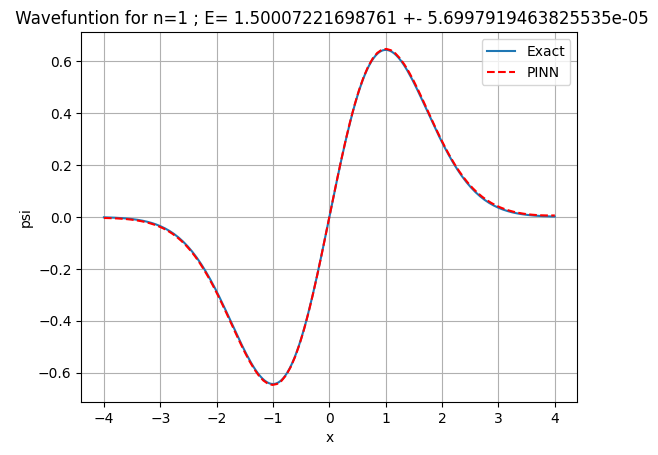

In [6]:
psi=model(x).detach()
model1 = nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,1))
ES1=[]
for n in range(5):
    E1=nn.Parameter(torch.tensor([1.0]))
    optimizer=optim.Adam(list(model1.parameters())+ [E1],lr=0.001)
    for i in range(5000):
        optimizer.zero_grad()
        V=0.5*(x**2)
        psi1=model1(x)
        psi_1 = torch.autograd.grad(psi1,x,grad_outputs=torch.ones_like(psi1),create_graph=True)[0]
        psi_2 = torch.autograd.grad(psi_1,x,grad_outputs=torch.ones_like(psi_1),create_graph=True)[0]
    #Loss
        Lpde=torch.mean(( -0.5*psi_2+ V*psi1 - E1*psi1)**2)
        dx=x[1]-x[0]
        Lnorm= ((torch.sum(psi1**2))*dx-1)**2
        xb=torch.tensor([[-4.0],[4.0]])
        psi_b=model1(xb)
        loss_bc=torch.mean(psi_b**2)
        lExcited=(torch.sum(psi*psi1)*dx)**2
        loss = Lpde+10*Lnorm+loss_bc+lExcited
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        psi1=model1(x)
    ES1.append(E1.item())
ES1=np.array(ES1)
mean1=np.mean(ES1)
error1 = np.std(ES1)
u=x.detach().numpy()
v=psi1.detach().numpy()
x_exact = np.linspace(-4, 4, 200)

psi_exact = np.sqrt(2) * np.pi**(-0.25) * x_exact * np.exp(-x_exact**2 / 2)

plt.plot(x_exact, psi_exact,label='Exact')
plt.plot(u,v,color='red',linestyle="--",label='PINN')
plt.xlabel('x')
plt.ylabel('psi')
plt.title(f' Wavefuntion for n=1 ; E= {mean1} +- {error1}')
plt.legend()
plt.grid(True)
plt.show()

    
    


    


    

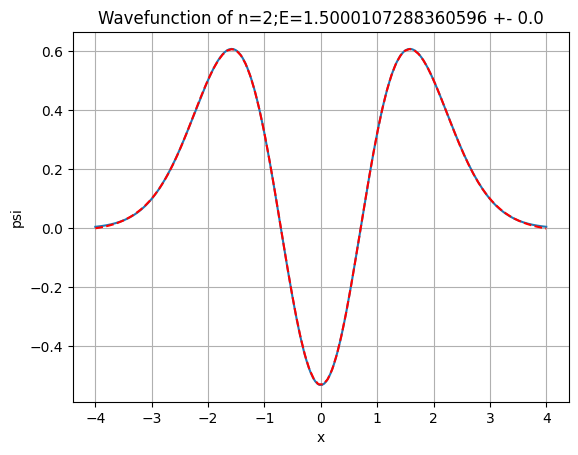

In [8]:
psi=model(x).detach()
model2 = nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,64),
    nn.Tanh(),
    nn.Linear(64,1))
ES2=[]
for n in range(5):
    E2=nn.Parameter(torch.tensor([1.0]))
    optimizer=optim.Adam(list(model2.parameters())+ [E2],lr=0.001)
    for i in range(5000):
        optimizer.zero_grad()
        V=0.5*(x**2)
        psi2=model2(x)
        psi_1 = torch.autograd.grad(psi2,x,grad_outputs=torch.ones_like(psi2),create_graph=True)[0]
        psi_2 = torch.autograd.grad(psi_1,x,grad_outputs=torch.ones_like(psi_1),create_graph=True)[0]
        # loss 
        dx=x[1]-x[0]
        Lorth0 = (torch.sum(psi * psi2) * dx)**2
        Lorth1 = (torch.sum(psi1 * psi2) * dx)**2
        lorth = Lorth0 + Lorth1
        Lpde=torch.mean(( -0.5*psi_2+ V*psi2 - E2*psi2)**2)
        Lnorm= ((torch.sum(psi2**2))*dx-1)**2
        xb=torch.tensor([[-4.0],[4.0]])
        psi_b=model2(xb)
        loss_bc=torch.mean(psi_b**2)
        loss = Lpde+100*Lnorm+50*loss_bc+100*lorth
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        psi2=model2(x)
    ES2.append(E1.item())
ES2=np.array(ES2)
mean2=np.mean(ES2)
error2=np.std(ES2)
u=x.detach().numpy()
v=psi2.detach().numpy()
x_exact = np.linspace(-4, 4, 200)

psi_exact = ((2*x_exact**2 - 1)* np.exp(-x_exact**2/2)/(np.sqrt(2)*np.pi**0.25))
plt.plot(x_exact, psi_exact,label='Exact')
plt.plot(u,v,color='red',linestyle="--",label='PINN')
plt.xlabel('x')
plt.ylabel('psi')
plt.title(f'Wavefunction of n=2;E={mean2} +- {error2}')
plt.grid(True)
plt.show()
dx = x[1] - x[0]

    
    


    


    